# Notebook 3 v3 - Core Modeling for Delay Risk and Resolution Time

1. Models a true delay-risk target using `delay_risk_48h_flag`.
2. Keeps same-day closure as a secondary operational target, not the main delay-risk claim.
3. Adds stronger final-report-ready metrics tables including ROC-AUC, PR-AUC, balanced accuracy, confusion matrices, regression MAE/RMSE/R², and threshold analysis.
4. Saves clean outputs for the final report appendix.


In [ ]:
import os
import gc
import json
import math
import time
import shutil
import zipfile
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)


# Upload notebook 2 outputs zip file

In [ ]:
# USER CONFIGURATION

# Preferred input is the ZIP from Notebook 2 v3.
NOTEBOOK2_ZIP = "/content/notebook2_v3_outputs.zip"
NOTEBOOK2_DIR = Path("/content/notebook2_v3_outputs")

# Fallback if running locally from an extracted folder.
MODEL_READY_PATH = NOTEBOOK2_DIR / "model_ready_sample_v3.parquet"

OUTPUT_DIR = Path("/content/notebook3_v3_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR = OUTPUT_DIR / "plots"
PLOT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.25

# To keep Standard Colab stable, limit tree-based models if the sample is huge.
MAX_TREE_MODEL_ROWS = 120_000
RUN_TS = datetime.now().strftime("%Y%m%d_%H%M%S")


In [ ]:
# LOAD NOTEBOOK 2 OUTPUT ZIP

import zipfile
import shutil
from pathlib import Path

NOTEBOOK2_ZIP = Path("/content/notebook2_v3_outputs.zip")
NOTEBOOK2_DIR = Path("/content/notebook2_v3_outputs_extracted")

print("Notebook 2 zip exists:", NOTEBOOK2_ZIP.exists())
print("Notebook 2 zip size:", NOTEBOOK2_ZIP.stat().st_size if NOTEBOOK2_ZIP.exists() else "missing")

# Validate that this is actually a zip file
if not zipfile.is_zipfile(NOTEBOOK2_ZIP):
    raise ValueError(
        f"{NOTEBOOK2_ZIP} is not a valid zip file. "
        "Recreate it in Notebook 2 using shutil.make_archive."
    )

if NOTEBOOK2_DIR.exists():
    shutil.rmtree(NOTEBOOK2_DIR)

NOTEBOOK2_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(NOTEBOOK2_ZIP, "r") as z:
    z.extractall(NOTEBOOK2_DIR)

print("Extracted Notebook 2 outputs to:", NOTEBOOK2_DIR)
print("Files found:")
for p in NOTEBOOK2_DIR.rglob("*"):
    print(p)

Notebook 2 zip exists: True
Notebook 2 zip size: 167498956
Extracted Notebook 2 outputs to: /content/notebook2_v3_outputs_extracted
Files found:
/content/notebook2_v3_outputs_extracted/transformation_rules_v3.csv
/content/notebook2_v3_outputs_extracted/repeat_key_chunks
/content/notebook2_v3_outputs_extracted/full_dataset_repeat_proxy_counts.csv
/content/notebook2_v3_outputs_extracted/notebook2_v3_manifest.json
/content/notebook2_v3_outputs_extracted/model_ready_sample_v3.parquet
/content/notebook2_v3_outputs_extracted/final_model_field_list_v3.csv
/content/notebook2_v3_outputs_extracted/repeat_proxy_sample_summary.csv
/content/notebook2_v3_outputs_extracted/analysis_ready_sample_v3.parquet
/content/notebook2_v3_outputs_extracted/repeat_key_chunks/repeat_counts_rg_0017.csv
/content/notebook2_v3_outputs_extracted/repeat_key_chunks/repeat_counts_rg_0006.csv
/content/notebook2_v3_outputs_extracted/repeat_key_chunks/repeat_counts_rg_0003.csv
/content/notebook2_v3_outputs_extracted/repeat_k

In [ ]:
ANALYSIS_READY_PATH = NOTEBOOK2_DIR / "model_ready_sample_v3.parquet"

if not ANALYSIS_READY_PATH.exists():
    matches = list(NOTEBOOK2_DIR.rglob("analysis_ready_sample.parquet"))
    if matches:
        ANALYSIS_READY_PATH = matches[0]
    else:
        raise FileNotFoundError(
            "Could not find analysis_ready_sample.parquet in extracted Notebook 2 outputs."
        )

print("Using:", ANALYSIS_READY_PATH)

df = pd.read_parquet(ANALYSIS_READY_PATH)

print(df.shape)
df.head()

# Ensure ZIP is treated as categorical, not numeric.
if "zip_code" in df.columns:
    df["zip_code"] = df["zip_code"].astype(str)

# Backward compatibility for older notebook logic.
if "agency" not in df.columns and "agency_name" in df.columns:
    df["agency"] = df["agency_name"]

if "incident_zip" not in df.columns and "zip_code" in df.columns:
    df["incident_zip"] = df["zip_code"]

Using: /content/notebook2_v3_outputs_extracted/model_ready_sample_v3.parquet
(487454, 55)


In [ ]:
import pandas as pd
import os

# FEATURE SETUP
# Main classification target for final report: true delay risk.
CLASS_TARGET = "delay_risk_48h_flag"

# Secondary classification target if you want to discuss same-day closure separately.
SECONDARY_TARGET = "closed_same_day_flag"

# Regression target.
REG_TARGET = "response_time_hours_capped_p99"

# Candidate features intentionally exclude leakage fields such as closed_date, raw response time,
# resolution text, and post-resolution fields.
# CATEGORICAL_FEATURES = [
#     "agency", "complaint_type", "borough", "location_type", "incident_zip",
#     "open_data_channel_type", "season", "address_type"
# ]
# NUMERIC_FEATURES = [
#     "created_month", "created_dayofweek", "created_hour", "is_weekend",
#     "latitude", "longitude", "repeat_group_count", "repeat_complaint_proxy"
# ]

# enriched dataset fields added
CATEGORICAL_FEATURES = [
    "agency_name",
    "complaint_type",
    "descriptor",
    "borough",
    "location_type",
    "zip_code",
    "open_data_channel_type",
    "season",
    "time_of_day",
    "address_type",
    "community_board",
    "precinct"
]

NUMERIC_FEATURES = [
    "created_month",
    "created_dayofweek",
    "created_hour",
    "is_weekend",
    "is_holiday",
    "latitude",
    "longitude",
    "repeat_group_count",
    "repeat_complaint_proxy",
    "possible_repeat_count",
    "permit_count",
    "white_pct",
    "black_pct",
    "hispanic_pct",
    "not_citizen_pct",
    "below_poverty_pct",
    "household_inc",
    "distance_to_precinct"
]

# Check if target columns exist in the DataFrame. If not, attempt to load the model-ready data.
if CLASS_TARGET not in df.columns or REG_TARGET not in df.columns:
    # Path to the model-ready dataset after extraction
    MODEL_READY_DATA_PATH = "/content/notebook2_v3_outputs_extracted/model_ready_sample_v3.parquet"
    if os.path.exists(MODEL_READY_DATA_PATH):
        print(f"Warning: Target columns '{CLASS_TARGET}' or '{REG_TARGET}' not found in current DataFrame. Attempting to load from {MODEL_READY_DATA_PATH}.")
        try:
            df = pd.read_parquet(MODEL_READY_DATA_PATH)
            print(f"Successfully loaded DataFrame from {MODEL_READY_DATA_PATH}.")
        except Exception as e:
            print(f"Error loading {MODEL_READY_DATA_PATH}: {e}. The original KeyError may persist.")
    else:
        print(f"Error: Model-ready data file not found at {MODEL_READY_DATA_PATH}. The KeyError will likely persist.")

CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c in df.columns]
NUMERIC_FEATURES = [c for c in NUMERIC_FEATURES if c in df.columns]

model_df = df.dropna(subset=[CLASS_TARGET, REG_TARGET]).copy()

# Downcast common numeric fields for memory stability.
for c in NUMERIC_FEATURES + [CLASS_TARGET, REG_TARGET]:
    if c in model_df.columns:
        model_df[c] = pd.to_numeric(model_df[c], errors="coerce")

print("Categorical features:", CATEGORICAL_FEATURES)
print("Numeric features:", NUMERIC_FEATURES)
print("Model rows:", f"{len(model_df):,}")
print("Delay risk rate:", model_df[CLASS_TARGET].mean())

Categorical features: ['agency_name', 'complaint_type', 'descriptor', 'borough', 'location_type', 'zip_code', 'open_data_channel_type', 'season', 'time_of_day', 'address_type', 'community_board', 'precinct']
Numeric features: ['created_month', 'created_dayofweek', 'created_hour', 'is_weekend', 'is_holiday', 'latitude', 'longitude', 'repeat_group_count', 'repeat_complaint_proxy', 'possible_repeat_count', 'permit_count', 'white_pct', 'black_pct', 'hispanic_pct', 'not_citizen_pct', 'below_poverty_pct', 'household_inc', 'distance_to_precinct']
Model rows: 487,454
Delay risk rate: 0.3285622848514937


In [ ]:
# PREPROCESSING PIPELINE
# min_frequency groups rare categorical levels together and keeps the one-hot matrix manageable.

try:
    ohe = OneHotEncoder(handle_unknown="ignore", min_frequency=25, sparse_output=True)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", min_frequency=25, sparse=True)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", ohe),
        ]), CATEGORICAL_FEATURES),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler(with_mean=False)),
        ]), NUMERIC_FEATURES),
    ],
    remainder="drop",
)

X = model_df[CATEGORICAL_FEATURES + NUMERIC_FEATURES]
y = model_df[CLASS_TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print("Train rows:", len(X_train), "Test rows:", len(X_test))


Train rows: 365590 Test rows: 121864



Training dummy_most_frequent


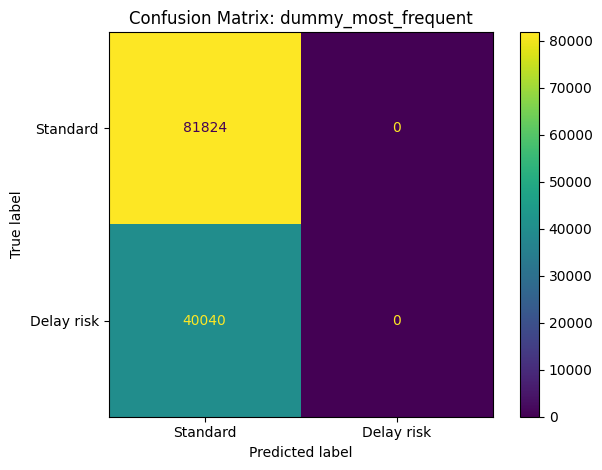


Training logistic_regression_balanced


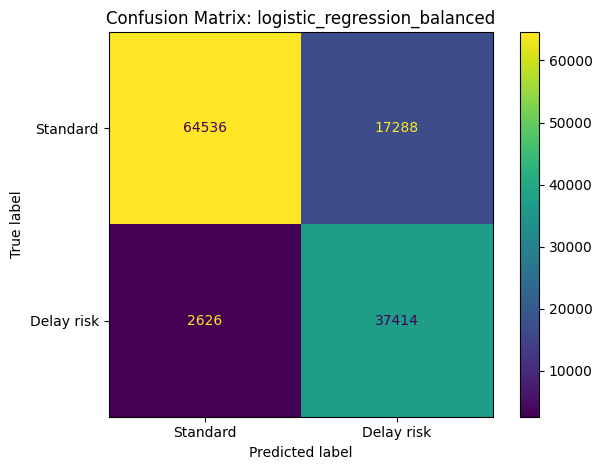


Training random_forest_balanced


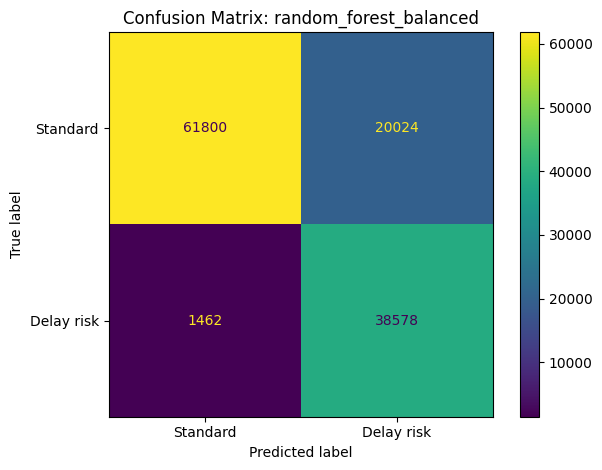

,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,positive_rate_test
1,logistic_regression_balanced,0.836588,0.861566,0.683960,0.934416,0.789808,0.937395,0.857030,0.328563
2,random_forest_balanced,0.823689,0.859383,0.658305,0.963487,0.782182,0.938371,0.859477,0.328563
0,dummy_most_frequent,0.671437,0.500000,0.000000,0.000000,0.000000,0.500000,0.328563,0.328563


In [ ]:
# CLASSIFICATION MODELS

classifiers = {
    "dummy_most_frequent": DummyClassifier(strategy="most_frequent"),
    "logistic_regression_balanced": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="saga",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "random_forest_balanced": RandomForestClassifier(
        n_estimators=250,
        max_depth=22,
        min_samples_leaf=10,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}

classification_rows = []
fitted_classifiers = {}

for name, model in classifiers.items():
    print("\nTraining", name)
    pipe = Pipeline([("preprocess", preprocess), ("model", model)])

    # Tree model uses a stable subset if the training data is very large.
    if name.startswith("random_forest") and len(X_train) > MAX_TREE_MODEL_ROWS:
        sub_idx = X_train.sample(n=MAX_TREE_MODEL_ROWS, random_state=RANDOM_STATE).index
        pipe.fit(X_train.loc[sub_idx], y_train.loc[sub_idx])
    else:
        pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)
    if hasattr(pipe.named_steps["model"], "predict_proba"):
        score = pipe.predict_proba(X_test)[:, 1]
    else:
        score = pred

    row = {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, score) if len(np.unique(y_test)) > 1 else np.nan,
        "pr_auc": average_precision_score(y_test, score) if len(np.unique(y_test)) > 1 else np.nan,
        "positive_rate_test": y_test.mean(),
    }
    classification_rows.append(row)
    fitted_classifiers[name] = pipe

    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Standard", "Delay risk"])
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix: {name}")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"confusion_matrix_{name}.png", dpi=160)
    plt.show()

classification_metrics = pd.DataFrame(classification_rows).sort_values("f1", ascending=False)
classification_metrics.to_csv(OUTPUT_DIR / "classification_metrics_delay_risk_48h.csv", index=False)
display(classification_metrics)


Best classifier by F1: logistic_regression_balanced


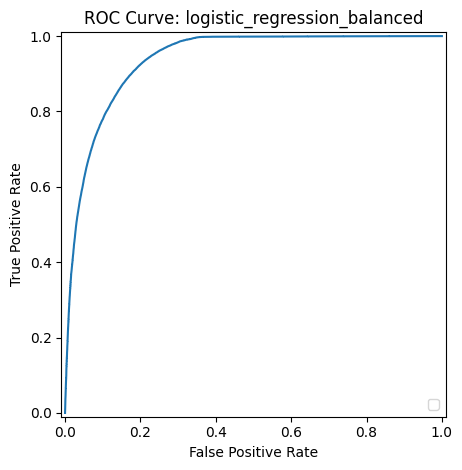

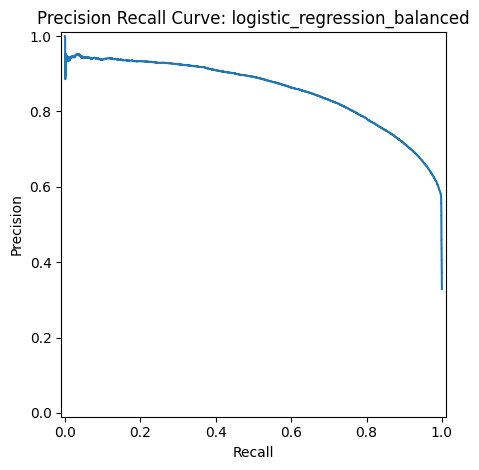

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

# ROC AND PR CURVES FOR BEST CLASSIFIER

best_class_model_name = classification_metrics.iloc[0]["model"]
best_class_pipe = fitted_classifiers[best_class_model_name]
print("Best classifier by F1:", best_class_model_name)

# Fix for ValueError: X has 853 features, but LogisticRegression is expecting 1078 features as input.
# The issue is that the 'preprocess' step within 'best_class_pipe' was likely
# corrupted or re-fitted on a different subset of data by a later model's training.
# To ensure correct feature counts for the best classifier, we recreate and
# fit a temporary preprocessor on the full X_train.

ohe_temp = OneHotEncoder(handle_unknown="ignore", min_frequency=25, sparse_output=True)
preprocess_temp = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", ohe_temp),
        ]), CATEGORICAL_FEATURES),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler(with_mean=False)),
        ]), NUMERIC_FEATURES),
    ],
    remainder="drop",
)

# Fit the temporary preprocessor on the full X_train to get the correct feature space
X_train_transformed_temp = preprocess_temp.fit_transform(X_train)
# Transform X_test using this correctly fitted preprocessor
X_test_transformed_temp = preprocess_temp.transform(X_test)

# Extract the fitted model from the best pipeline
best_model = best_class_pipe.named_steps["model"]

if hasattr(best_model, "predict_proba"):
    # Get prediction scores from the correctly transformed X_test
    y_score = best_model.predict_proba(X_test_transformed_temp)[:, 1]

    # Plot ROC Curve manually
    fpr, tpr, _ = roc_curve(y_test, y_score)
    RocCurveDisplay(fpr=fpr, tpr=tpr).plot()
    plt.title(f"ROC Curve: {best_class_model_name}")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"roc_curve_{best_class_model_name}.png", dpi=160)
    plt.show()

    # Plot Precision-Recall Curve manually
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    PrecisionRecallDisplay(precision=precision, recall=recall).plot()
    plt.title(f"Precision Recall Curve: {best_class_model_name}")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"pr_curve_{best_class_model_name}.png", dpi=160)
    plt.show()


,threshold,precision,recall,f1,flagged_share
0,0.10,0.588219,0.994580,0.739236,0.555546
1,0.15,0.590933,0.993282,0.741015,0.552271
2,0.20,0.595216,0.991783,0.743951,0.547471
3,0.25,0.603418,0.989311,0.749617,0.538682
4,0.30,0.616179,0.983516,0.757672,0.524437
5,0.35,0.632071,0.974500,0.766792,0.506565
6,0.40,0.649148,0.963362,0.775641,0.487601
7,0.45,0.665338,0.950699,0.782824,0.469482
8,0.50,0.683960,0.934416,0.789808,0.448877
9,0.55,0.707235,0.908966,0.795510,0.422282


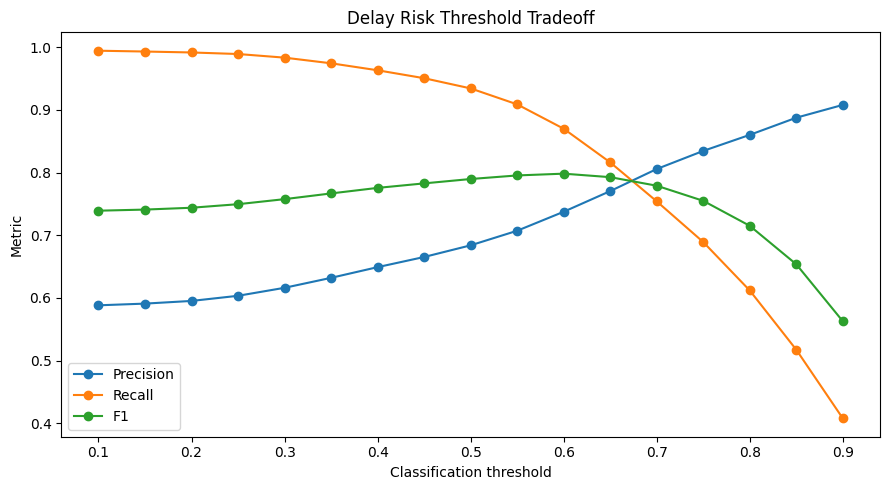

In [ ]:
# THRESHOLD TUNING TABLE
# This table lets management choose whether recall or precision matters more.
# The `best_model` and `X_test_transformed_temp` are assumed to be available
# from the execution of the previous cell (b81607b0), which fixed the
# feature mismatch issue.

if hasattr(best_model, "predict_proba"):
    scores = best_model.predict_proba(X_test_transformed_temp)[:, 1]
    threshold_rows = []
    for threshold in np.arange(0.10, 0.91, 0.05):
        pred_t = (scores >= threshold).astype(int)
        threshold_rows.append({
            "threshold": round(float(threshold), 2),
            "precision": precision_score(y_test, pred_t, zero_division=0),
            "recall": recall_score(y_test, pred_t, zero_division=0),
            "f1": f1_score(y_test, pred_t, zero_division=0),
            "flagged_share": pred_t.mean(),
        })
    threshold_table = pd.DataFrame(threshold_rows)
    threshold_table.to_csv(OUTPUT_DIR / "classification_threshold_curve_delay_risk_48h.csv", index=False)
    display(threshold_table)

    plt.figure(figsize=(9, 5))
    plt.plot(threshold_table["threshold"], threshold_table["precision"], marker="o", label="Precision")
    plt.plot(threshold_table["threshold"], threshold_table["recall"], marker="o", label="Recall")
    plt.plot(threshold_table["threshold"], threshold_table["f1"], marker="o", label="F1")
    plt.title("Delay Risk Threshold Tradeoff")
    plt.xlabel("Classification threshold")
    plt.ylabel("Metric")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "threshold_tradeoff_delay_risk_48h.png", dpi=160)
    plt.show()


In [ ]:
# REGRESSION MODELS

reg_df = model_df.dropna(subset=[REG_TARGET]).copy()
Xr = reg_df[CATEGORICAL_FEATURES + NUMERIC_FEATURES]
yr = reg_df[REG_TARGET].astype(float)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

regressors = {
    "dummy_median": DummyRegressor(strategy="median"),
    "ridge_regression": Ridge(alpha=2.0, random_state=RANDOM_STATE),
    "random_forest_regressor": RandomForestRegressor(
        n_estimators=200,
        max_depth=24,
        min_samples_leaf=10,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}

regression_rows = []
fitted_regressors = {}

for name, model in regressors.items():
    print("\nTraining", name)
    pipe = Pipeline([("preprocess", preprocess), ("model", model)])
    if name.startswith("random_forest") and len(Xr_train) > MAX_TREE_MODEL_ROWS:
        sub_idx = Xr_train.sample(n=MAX_TREE_MODEL_ROWS, random_state=RANDOM_STATE).index
        pipe.fit(Xr_train.loc[sub_idx], yr_train.loc[sub_idx])
    else:
        pipe.fit(Xr_train, yr_train)

    pred = pipe.predict(Xr_test)
    # Fix for TypeError: got an unexpected keyword argument 'squared'
    rmse = np.sqrt(mean_squared_error(yr_test, pred))
    row = {
        "model": name,
        "mae_hours": mean_absolute_error(yr_test, pred),
        "rmse_hours": rmse,
        "r2": r2_score(yr_test, pred),
        "target": REG_TARGET,
    }
    regression_rows.append(row)
    fitted_regressors[name] = pipe

regression_metrics = pd.DataFrame(regression_rows).sort_values("rmse_hours")
regression_metrics.to_csv(OUTPUT_DIR / "regression_metrics_response_time.csv", index=False)
display(regression_metrics)



Training dummy_median

Training ridge_regression

Training random_forest_regressor


,model,mae_hours,rmse_hours,r2,target
2,random_forest_regressor,276.057591,948.392955,0.612917,response_time_hours_capped_p99
1,ridge_regression,371.981917,1077.106746,0.500719,response_time_hours_capped_p99
0,dummy_median,358.616037,1564.601632,-0.053502,response_time_hours_capped_p99


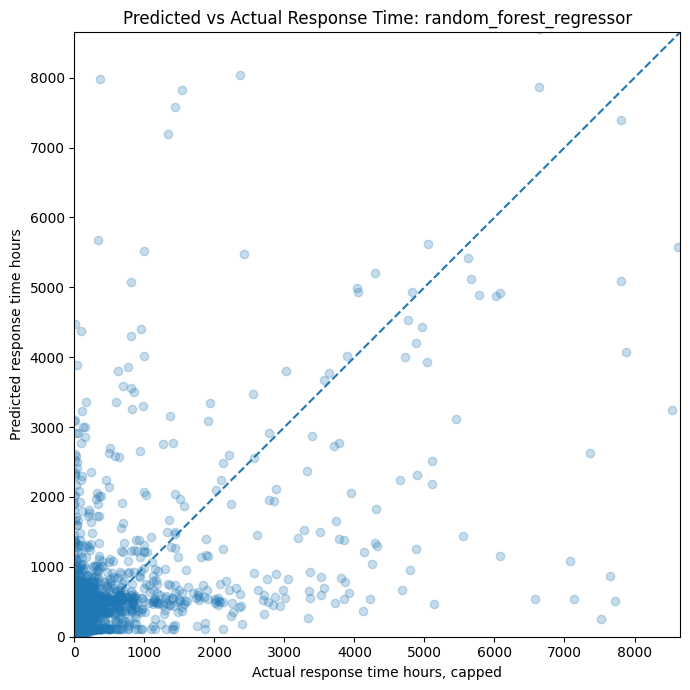

In [ ]:
# REGRESSION PREDICTED VS ACTUAL PLOT

best_reg_name = regression_metrics.iloc[0]["model"]
best_reg_pipe = fitted_regressors[best_reg_name]
pred = best_reg_pipe.predict(Xr_test)

plot_df = pd.DataFrame({"actual": yr_test, "predicted": pred}).sample(
    n=min(5000, len(yr_test)), random_state=RANDOM_STATE
)
plt.figure(figsize=(7, 7))
plt.scatter(plot_df["actual"], plot_df["predicted"], alpha=0.25)
max_val = np.nanpercentile(plot_df[["actual", "predicted"]].values, 99)
plt.plot([0, max_val], [0, max_val], linestyle="--")
plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.title(f"Predicted vs Actual Response Time: {best_reg_name}")
plt.xlabel("Actual response time hours, capped")
plt.ylabel("Predicted response time hours")
plt.tight_layout()
plt.savefig(PLOT_DIR / f"predicted_vs_actual_{best_reg_name}.png", dpi=160)
plt.show()


In [ ]:
# FEATURE IMPORTANCE FOR INTERPRETABLE MODELS

def get_feature_names(pipe):
    pre = pipe.named_steps["preprocess"]
    names = []
    if "cat" in pre.named_transformers_:
        cat_pipe = pre.named_transformers_["cat"]
        try:
            cat_names = cat_pipe.named_steps["onehot"].get_feature_names_out(CATEGORICAL_FEATURES).tolist()
        except Exception:
            cat_names = []
        names.extend(cat_names)
    names.extend(NUMERIC_FEATURES)
    return np.array(names, dtype=object)

# Logistic coefficients if available.
if "logistic_regression_balanced" in fitted_classifiers:
    pipe = fitted_classifiers["logistic_regression_balanced"]
    names = get_feature_names(pipe)
    coef = pipe.named_steps["model"].coef_[0]
    n = min(len(names), len(coef))
    coef_df = pd.DataFrame({"feature": names[:n], "coefficient": coef[:n]})
    coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
    coef_df.sort_values("abs_coefficient", ascending=False).head(50).to_csv(
        OUTPUT_DIR / "top_logistic_coefficients_delay_risk.csv", index=False
    )
    display(coef_df.sort_values("abs_coefficient", ascending=False).head(20))

# Random forest importance if available.
if "random_forest_balanced" in fitted_classifiers:
    pipe = fitted_classifiers["random_forest_balanced"]
    names = get_feature_names(pipe)
    imp = pipe.named_steps["model"].feature_importances_
    n = min(len(names), len(imp))
    imp_df = pd.DataFrame({"feature": names[:n], "importance": imp[:n]})
    imp_df = imp_df.sort_values("importance", ascending=False)
    imp_df.head(50).to_csv(OUTPUT_DIR / "top_random_forest_importance_delay_risk.csv", index=False)
    display(imp_df.head(20))


,feature,coefficient,abs_coefficient
14,agency_name_TAXI AND LIMOUSINE COMMISSION,-3.401108,3.401108
704,community_board_03 QUEENS,-1.785669,1.785669
67,complaint_type_INDUSTRIAL WASTE,-1.344228,1.344228
692,community_board_01 BROOKLYN,1.099046,1.099046
8,agency_name_DEPARTMENT OF PARKS AND RECREATION,0.957948,0.957948
144,descriptor_1R MISSED RECYCLING-ALL MATERIALS,-0.913139,0.913139
329,descriptor_NON-CHRONIC,-0.825820,0.825820
74,complaint_type_MAINTENANCE OR FACILITY,-0.824157,0.824157
154,"descriptor_AIR: SMOKE, VEHICULAR (AA4)",-0.803483,0.803483
42,complaint_type_DRUG ACTIVITY,-0.770671,0.770671


,feature,importance
13,agency_name_NEW YORK CITY POLICE DEPARTMENT,0.165757
489,location_type_STREET,0.126612
481,location_type_PUBLIC/UNFENCED AREA,0.063945
7,agency_name_DEPARTMENT OF HOUSING PRESERVATION...,0.054064
63,complaint_type_ILLEGAL PARKING,0.041171
482,location_type_RESIDENTIAL,0.036652
84,complaint_type_NOISE - RESIDENTIAL,0.034485
301,descriptor_LOUD TALKING,0.032700
667,zip_code_11692,0.020812
842,created_hour,0.016408


In [ ]:
# FINAL REPORT SUMMARY TABLES

summary_rows = [
    {"finding_area": "classification", "finding": f"Best delay-risk model by F1 was {best_class_model_name}."},
    {"finding_area": "regression", "finding": f"Best response-time regression model by RMSE was {best_reg_name}."},
    {"finding_area": "target", "finding": "The main classification target is delay_risk_48h_flag, not same-day closure."},
    {"finding_area": "operations", "finding": "Threshold table should be used to choose a management operating point based on recall versus precision."},
]
report_findings = pd.DataFrame(summary_rows)
report_findings.to_csv(OUTPUT_DIR / "report_ready_modeling_findings.csv", index=False)

with pd.ExcelWriter(OUTPUT_DIR / "notebook3_v3_modeling_results.xlsx") as writer:
    classification_metrics.to_excel(writer, sheet_name="classification_metrics", index=False)
    regression_metrics.to_excel(writer, sheet_name="regression_metrics", index=False)
    if 'threshold_table' in globals():
        threshold_table.to_excel(writer, sheet_name="threshold_curve", index=False)
    report_findings.to_excel(writer, sheet_name="report_findings", index=False)

manifest = {
    "run_timestamp": RUN_TS,
    "input_model_ready_path": str(MODEL_READY_PATH),
    "output_dir": str(OUTPUT_DIR),
    "class_target": CLASS_TARGET,
    "regression_target": REG_TARGET,
    "best_class_model_by_f1": str(best_class_model_name),
    "best_regression_model_by_rmse": str(best_reg_name),
    "important_note": "Notebook 3 v3 uses a true delay-risk target and final-report-ready metrics."
}
with open(OUTPUT_DIR / "notebook3_v3_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)
print(json.dumps(manifest, indent=2))


{
  "run_timestamp": "20260512_104700",
  "input_model_ready_path": "/content/notebook2_v3_outputs/model_ready_sample_v3.parquet",
  "output_dir": "/content/notebook3_v3_outputs",
  "class_target": "delay_risk_48h_flag",
  "regression_target": "response_time_hours_capped_p99",
  "best_class_model_by_f1": "logistic_regression_balanced",
  "best_regression_model_by_rmse": "random_forest_regressor",
  "important_note": "Notebook 3 v3 uses a true delay-risk target and final-report-ready metrics."
}


In [ ]:

# CREATE NOTEBOOK 3 OUTPUT ZIP

import shutil
from pathlib import Path

NOTEBOOK2_OUTPUT_DIR = Path("/content/notebook3_v3_outputs")
ZIP_BASE = Path("/content/notebook3_v3_outputs")

# This creates /content/notebook3_v3_outputs.zip
zip_path = shutil.make_archive(
    base_name=str(ZIP_BASE),
    format="zip",
    root_dir=str(NOTEBOOK2_OUTPUT_DIR)
)

print("Created zip:", zip_path)
print("Upload or download this file for Notebook 3:")
print(zip_path)

Created zip: /content/notebook3_v3_outputs.zip
Upload or download this file for Notebook 3:
/content/notebook3_v3_outputs.zip
